# Smart Meters in London: General Statistics / EDA

General Statistics of the Data section for the kick-off document.

- Number of records
- Number of features/columns, data types
- Missing values
- Sample distributions (histograms, pie charts)
- Column distributions (numeric stats, categorical value counts)

## Setup

In [2]:
from pathlib import Path

import kagglehub
import pandas as pd
import matplotlib.pyplot as plt

## 0. Download & inspect dataset

```
Kaggle API credentials: kaggle.com -> Settings -> API -> Create New Token
```

In [3]:
path = kagglehub.dataset_download("jeanmidev/smart-meters-in-london")
dataset_dir = Path(path)

In [4]:
def summarize_tree(dir_path, prefix=""):
    """Print a folder-structure tree with per-item size; collapse a directory's
    files into one summary line once there are more than 5 (e.g. block_*.csv)."""
    entries = sorted(dir_path.iterdir(), key=lambda p: (p.is_file(), p.name.lower()))
    n_files, size_mb = 0, 0.0
    for i, entry in enumerate(entries):
        last = i == len(entries) - 1
        connector = "└── " if last else "├── "
        extension = "    " if last else "│   "
        if entry.is_dir():
            children = sorted(entry.iterdir())
            child_files = [c for c in children if c.is_file()]
            child_dirs = [c for c in children if c.is_dir()]
            if child_files and not child_dirs and len(child_files) > 5:
                names = sorted(c.name for c in child_files)
                sizes = [c.stat().st_size / (1024 ** 2) for c in child_files]
                total = sum(sizes)
                print(f"{prefix}{connector}{entry.name}/  [{names[0]} .. {names[-1]}]  "
                      f"({len(child_files)} files, {total:,.1f} MB)")
                n_files += len(child_files)
                size_mb += total
            else:
                print(f"{prefix}{connector}{entry.name}/")
                sub_n, sub_mb = summarize_tree(entry, prefix + extension)
                n_files += sub_n
                size_mb += sub_mb
        else:
            item_mb = entry.stat().st_size / (1024 ** 2)
            print(f"{prefix}{connector}{entry.name}  ({item_mb:,.1f} MB)")
            n_files += 1
            size_mb += item_mb
    return n_files, size_mb


print(f"Dataset directory: {dataset_dir}\n")
total_files, total_size_mb = summarize_tree(dataset_dir)

EXPECTED_FILE_COUNT = 343  # confirmed count for kagglehub dataset version 21; re-check if the version changes
print(f"\nTotal: {total_files}/{EXPECTED_FILE_COUNT} files, {total_size_mb / 1024:,.2f} GB on disk "
      f"(counts above are for dataset version {dataset_dir.name})")

Dataset directory: C:\Users\purin\.cache\kagglehub\datasets\jeanmidev\smart-meters-in-london\versions\21

├── daily_dataset/
│   └── daily_dataset/  [block_0.csv .. block_99.csv]  (112 files, 357.1 MB)
├── halfhourly_dataset/
│   └── halfhourly_dataset/  [block_0.csv .. block_99.csv]  (112 files, 7,501.3 MB)
├── hhblock_dataset/
│   └── hhblock_dataset/  [block_0.csv .. block_99.csv]  (112 files, 1,593.8 MB)
├── acorn_details.csv  (0.1 MB)
├── daily_dataset.csv  (335.5 MB)
├── darksky_parameters_documentation.html  (0.1 MB)
├── informations_households.csv  (0.2 MB)
├── uk_bank_holidays.csv  (0.0 MB)
├── weather_daily_darksky.csv  (0.3 MB)
└── weather_hourly_darksky.csv  (1.9 MB)

Total: 343/343 files, 9.56 GB on disk (counts above are for dataset version 21)


## 1. Number of records

In [5]:
household_info = pd.read_csv(dataset_dir / "informations_households.csv")

other_top_level_files = [
    "acorn_details.csv",
    "daily_dataset.csv",
    "uk_bank_holidays.csv",
    "weather_daily_darksky.csv",
    "weather_hourly_darksky.csv",
]  # darksky_parameters_documentation.html excluded below: not tabular
counted_top_level_files = ["informations_households.csv"] + other_top_level_files


def peek_first_line(path):
    with open(path, "rb") as f:
        return f.readline().decode("utf-8", errors="replace").rstrip("\r\n")


def looks_like_header(line):
    """A header row is pure text labels; every data row in this dataset has at
    least one field that parses as a plain number. No field parsing as a
    number is treated as evidence the line is a header, not data."""
    def is_number(field):
        try:
            float(field.strip())
            return True
        except ValueError:
            return False
    return not any(is_number(f) for f in line.split(","))


print("Header check, counted top-level files:")
print(f"  {'informations_households.csv':<32} columns: {list(household_info.columns)}")
for name in other_top_level_files:
    line = peek_first_line(dataset_dir / name)
    status = "header OK" if looks_like_header(line) else "NO HEADER DETECTED"
    print(f"  {name:<32} [{status}]  {line[:90]}")

print("\nHeader check, block_*.csv files (every file, first line only):")
for folder in ["daily_dataset", "halfhourly_dataset", "hhblock_dataset"]:
    files = sorted((dataset_dir / folder).rglob("block_*.csv"))
    missing_header = [f.name for f in files if not looks_like_header(peek_first_line(f))]
    print(f"  {folder:<20} {len(files)} files checked, "
          f"{len(files) - len(missing_header)} with a header, {len(missing_header)} without"
          + (f"  -> {missing_header[:5]}" if missing_header else ""))

top_level_files = sorted(p.name for p in dataset_dir.iterdir() if p.is_file())
excluded_files = sorted(set(top_level_files) - set(counted_top_level_files))
print(f"\nTop-level files on disk: {len(top_level_files)}")
print(f"Counted in record totals: {len(counted_top_level_files)}")
print(f"Excluded from record totals: {excluded_files}")

Header check, counted top-level files:
  informations_households.csv      columns: ['LCLid', 'stdorToU', 'Acorn', 'Acorn_grouped', 'file']
  acorn_details.csv                [header OK]  MAIN CATEGORIES,CATEGORIES,REFERENCE,ACORN-A,ACORN-B,ACORN-C,ACORN-D,ACORN-E,ACORN-F,ACORN
  daily_dataset.csv                [header OK]  LCLid,day,energy_median,energy_mean,energy_max,energy_count,energy_std,energy_sum,energy_m
  uk_bank_holidays.csv             [header OK]  Bank holidays,Type
  weather_daily_darksky.csv        [header OK]  temperatureMax,temperatureMaxTime,windBearing,icon,dewPoint,temperatureMinTime,cloudCover,
  weather_hourly_darksky.csv       [header OK]  visibility,windBearing,temperature,time,dewPoint,pressure,apparentTemperature,windSpeed,pr

Header check, block_*.csv files (every file, first line only):
  daily_dataset        112 files checked, 112 with a header, 0 without
  halfhourly_dataset   112 files checked, 112 with a header, 0 without
  hhblock_dataset      112 files

In [6]:
def count_csv_rows(path, chunk_size=8 * 1024 * 1024):
    """Count data rows in a CSV via chunked newline counts (no parsing, no full load)."""
    n = 0
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            n += chunk.count(b"\n")
    return n - 1  # exclude header row


print("Records per top-level file:")
file_counts = {"informations_households.csv": len(household_info)}
print(f"  {'informations_households.csv':<32} {len(household_info):>12,} records")
for name in other_top_level_files:
    n = count_csv_rows(dataset_dir / name)
    file_counts[name] = n
    print(f"  {name:<32} {n:>12,} records")

print("\nRecords per top-level folder (aggregated across all block_*.csv files):")
folder_counts = {}
for folder in ["daily_dataset", "halfhourly_dataset", "hhblock_dataset"]:
    files = sorted((dataset_dir / folder).rglob("block_*.csv"))
    n = sum(count_csv_rows(f) for f in files)
    folder_counts[folder] = n
    print(f"  {folder:<32} {n:>12,} records  ({len(files)} files)")

# daily_dataset.csv duplicates the daily_dataset/ folder: same 3,510,433 rows, same 9
# columns, sampled values match to within floating-point noise (~1e-14). Excluded from
# the grand total to avoid double-counting; its own count is still shown above.
DUPLICATE_TOP_LEVEL_FILES = {"daily_dataset.csv"}
grand_total = (sum(n for name, n in file_counts.items() if name not in DUPLICATE_TOP_LEVEL_FILES)
               + sum(folder_counts.values()))
print(f"\nGrand total: {grand_total:,} records "
      f"({', '.join(DUPLICATE_TOP_LEVEL_FILES)} excluded: duplicates the daily_dataset/ folder)")

Records per top-level file:
  informations_households.csv             5,566 records
  acorn_details.csv                         826 records
  daily_dataset.csv                   3,510,433 records
  uk_bank_holidays.csv                       25 records
  weather_daily_darksky.csv                 882 records
  weather_hourly_darksky.csv             21,165 records

Records per top-level folder (aggregated across all block_*.csv files):
  daily_dataset                       3,510,433 records  (112 files)
  halfhourly_dataset                167,817,021 records  (112 files)
  hhblock_dataset                     3,469,352 records  (112 files)

Grand total: 174,825,270 records (daily_dataset.csv excluded: duplicates the daily_dataset/ folder)


## 2. Number of features / columns, data types

In [7]:
FILE_ENCODING = {"acorn_details.csv": "cp1252"}  # contains a £ byte; not valid UTF-8
SAMPLE_ROWS = 20_000  # dtype-inference sample, not a full load (daily_dataset.csv alone is 3.5M rows)


def summarize_dtypes(dtypes):
    """dtypes: a pandas dtypes Series. Collapse a run of more than 5 consecutive
    same-dtype columns (e.g. hh_0..hh_47) into one line, matching the tree-view
    collapsing convention used for the block_*.csv listing in Section 0."""
    items = list(dtypes.items())
    i = 0
    while i < len(items):
        j = i
        while j + 1 < len(items) and items[j + 1][1] == items[i][1]:
            j += 1
        run = items[i:j + 1]
        if len(run) > 5:
            print(f"    [{run[0][0]} .. {run[-1][0]}]  ({len(run)} columns, {run[0][1]})")
        else:
            for col, dtype in run:
                print(f"    {col:<28} {dtype}")
        i = j + 1


print("Columns & dtypes per top-level file:\n")
print(f"  informations_households.csv  ({household_info.shape[1]} columns, full file)")
summarize_dtypes(household_info.dtypes)

for name in other_top_level_files:
    sample = pd.read_csv(dataset_dir / name, nrows=SAMPLE_ROWS, encoding=FILE_ENCODING.get(name, "utf-8"))
    note = "full file" if len(sample) < SAMPLE_ROWS else f"first {SAMPLE_ROWS:,} rows"
    print(f"\n  {name}  ({sample.shape[1]} columns, {note})")
    summarize_dtypes(sample.dtypes)

print("\n\nColumns & dtypes per top-level folder "
      f"(one sample block_*.csv, first {SAMPLE_ROWS:,} rows; "
      "header checked against every file in the folder):\n")
for folder in ["daily_dataset", "halfhourly_dataset", "hhblock_dataset"]:
    files = sorted((dataset_dir / folder).rglob("block_*.csv"))
    headers = {peek_first_line(f) for f in files}
    consistency = (f"same header across all {len(files)} files" if len(headers) == 1
                   else f"{len(headers)} DISTINCT HEADERS across {len(files)} files -- INCONSISTENT")
    sample = pd.read_csv(files[0], nrows=SAMPLE_ROWS)
    print(f"  {folder}  ({sample.shape[1]} columns, {consistency})")
    summarize_dtypes(sample.dtypes)

Columns & dtypes per top-level file:

  informations_households.csv  (5 columns, full file)
    LCLid                        str
    stdorToU                     str
    Acorn                        str
    Acorn_grouped                str
    file                         str

  acorn_details.csv  (20 columns, full file)
    MAIN CATEGORIES              str
    CATEGORIES                   str
    REFERENCE                    str
    [ACORN-A .. ACORN-Q]  (17 columns, float64)

  daily_dataset.csv  (9 columns, first 20,000 rows)
    LCLid                        str
    day                          str
    energy_median                float64
    energy_mean                  float64
    energy_max                   float64
    energy_count                 int64
    energy_std                   float64
    energy_sum                   float64
    energy_min                   float64

  uk_bank_holidays.csv  (2 columns, full file)
    Bank holidays                str
    Type             

**`energy(kWh/hh)` reads as `str`, not numeric.** This dataset uses the literal string `"Null"` as its missing-value sentinel instead of a blank field, and pandas' default dtype inference doesn't coerce that to NaN.

Exact figures from Section 3's full scan (all 112 `halfhourly_dataset` files, no sampling):
- 5,560 `"Null"` values in `energy(kWh/hh)` out of 167,817,021 rows (0.003%)
- 0 real NaN in that column

**Fixed in Section 3**: `halfhourly_dataset` reads pass `na_values=["Null"]` to `read_csv`, so `energy(kWh/hh)` loads as `float64` (the 5,560 former `"Null"` values now count as NaN there instead).

## 3. Missing values: NaN and literal `"Null"` strings

In [8]:
FOLDER_NA_VALUES = {"halfhourly_dataset": ["Null"]}  # coerce energy(kWh/hh) to float64 at read time


def missing_summary(df, label, expected_rows=None):
    """Print only the columns that actually have missing values (NaN or the
    literal "Null" string this dataset uses); silent on clean columns."""
    if expected_rows is not None:
        assert len(df) == expected_rows, f"{label}: row count mismatch ({len(df)} vs {expected_rows})"
    nan_counts = df.isna().sum()
    null_counts = (df == "Null").sum()
    nan_cols = nan_counts[nan_counts > 0]
    null_cols = null_counts[null_counts > 0]
    print(f"  {label}  ({len(df):,} rows x {df.shape[1]} columns)")
    if nan_cols.empty and null_cols.empty:
        print("    no NaN or literal \"Null\" values found")
    for col, n in nan_cols.items():
        print(f"    NaN     {col:<28} {int(n):>12,}  ({n / len(df):.3%} of rows)")
    for col, n in null_cols.items():
        print(f"    \"Null\"  {col:<28} {int(n):>12,}  ({n / len(df):.3%} of rows)")
    return nan_counts, null_counts


print("Missing values per top-level file:\n")
missing_summary(household_info, "informations_households.csv", file_counts["informations_households.csv"])
for name in other_top_level_files:
    df = pd.read_csv(dataset_dir / name, encoding=FILE_ENCODING.get(name, "utf-8"))
    missing_summary(df, name, file_counts[name])
    del df

print("\nMissing values per top-level folder (aggregated across all block_*.csv files, "
      "one file loaded at a time, not concatenated):\n")
for folder in ["daily_dataset", "halfhourly_dataset", "hhblock_dataset"]:
    files = sorted((dataset_dir / folder).rglob("block_*.csv"))
    total_rows = 0
    nan_totals = null_totals = None
    energy_dtype = None
    for f in files:
        df = pd.read_csv(f, na_values=FOLDER_NA_VALUES.get(folder))
        total_rows += len(df)
        nan = df.isna().sum()
        null = (df == "Null").sum()
        nan_totals = nan if nan_totals is None else nan_totals.add(nan, fill_value=0)
        null_totals = null if null_totals is None else null_totals.add(null, fill_value=0)
        if folder == "halfhourly_dataset":
            energy_dtype = df["energy(kWh/hh)"].dtype
        del df
    assert total_rows == folder_counts[folder], f"{folder}: row total mismatch"
    nan_cols = nan_totals[nan_totals > 0]
    null_cols = null_totals[null_totals > 0]
    print(f"  {folder}  ({total_rows:,} rows across {len(files)} files)")
    if nan_cols.empty and null_cols.empty:
        print("    no NaN or literal \"Null\" values found")
    for col, n in nan_cols.items():
        print(f"    NaN     {col:<28} {int(n):>12,}  ({n / total_rows:.3%} of rows)")
    for col, n in null_cols.items():
        print(f"    \"Null\"  {col:<28} {int(n):>12,}  ({n / total_rows:.3%} of rows)")
    if energy_dtype is not None:
        print(f"    (energy(kWh/hh) dtype after na_values fix: {energy_dtype})")
    print()

Missing values per top-level file:

  informations_households.csv  (5,566 rows x 5 columns)
    no NaN or literal "Null" values found
  acorn_details.csv  (826 rows x 20 columns)
    NaN     REFERENCE                               1  (0.121% of rows)
  daily_dataset.csv  (3,510,433 rows x 9 columns)
    NaN     energy_median                          30  (0.001% of rows)
    NaN     energy_mean                            30  (0.001% of rows)
    NaN     energy_max                             30  (0.001% of rows)
    NaN     energy_std                         11,331  (0.323% of rows)
    NaN     energy_sum                             30  (0.001% of rows)
    NaN     energy_min                             30  (0.001% of rows)
  uk_bank_holidays.csv  (25 rows x 2 columns)
    no NaN or literal "Null" values found
  weather_daily_darksky.csv  (882 rows x 32 columns)
    NaN     cloudCover                              1  (0.113% of rows)
    NaN     uvIndex                                 1 

## 4. Sample distributions

### Consumption histogram

block_0.csv: 1,222,670 rows, 1,222,620 non-missing readings used below


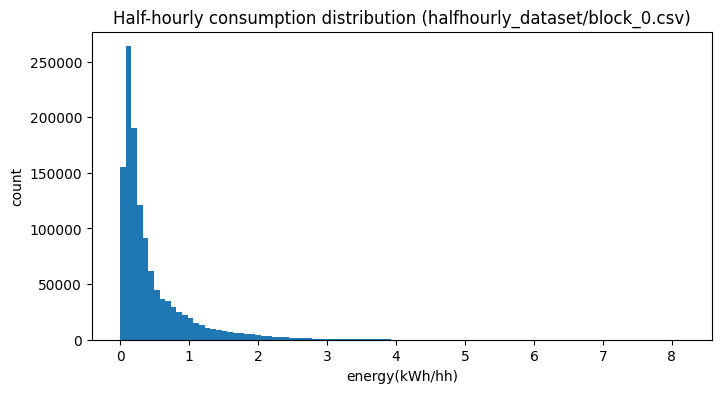

count    1.222620e+06
mean     4.506402e-01
std      5.433093e-01
min      0.000000e+00
25%      1.270000e-01
50%      2.470000e-01
75%      5.500000e-01
max      8.171000e+00
Name: energy(kWh/hh), dtype: float64


In [9]:
sample_block = pd.read_csv(
    dataset_dir / "halfhourly_dataset" / "halfhourly_dataset" / "block_0.csv",
    na_values=FOLDER_NA_VALUES["halfhourly_dataset"],
)
readings = sample_block["energy(kWh/hh)"].dropna()
print(f"block_0.csv: {len(sample_block):,} rows, {len(readings):,} non-missing readings used below")

plt.figure(figsize=(8, 4))
plt.hist(readings, bins=100)
plt.xlabel("energy(kWh/hh)")
plt.ylabel("count")
plt.title("Half-hourly consumption distribution (halfhourly_dataset/block_0.csv)")
plt.show()

print(readings.describe())

### Tariff type pie chart

stdorToU
Std    4443
ToU    1123
Name: count, dtype: int64


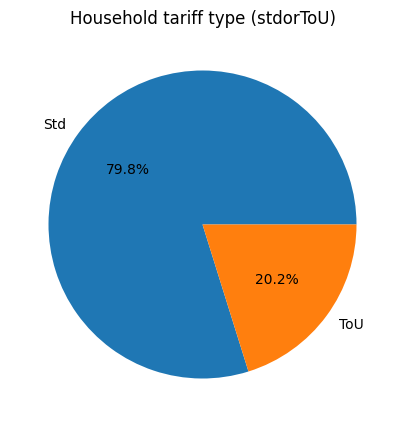

In [10]:
tariff_counts = household_info["stdorToU"].value_counts()
print(tariff_counts)

plt.figure(figsize=(5, 5))
plt.pie(tariff_counts, labels=tariff_counts.index, autopct="%1.1f%%")
plt.title("Household tariff type (stdorToU)")
plt.show()

## 5. Column distributions

In [11]:
def summarize_column_distributions(df, label):
    """Numeric columns: full describe(). Categorical/string columns: full value_counts()
    if low-cardinality (<=20 unique), else just the top 5 plus the unique count."""
    print(f"  {label}  ({len(df):,} rows)")
    for col in df.columns:
        s = df[col]
        if pd.api.types.is_numeric_dtype(s):
            d = s.describe()
            print(f"    {col:<28} numeric      count={int(d['count']):,}  mean={d['mean']:.4g}  "
                  f"std={d['std']:.4g}  min={d['min']:.4g}  25%={d['25%']:.4g}  "
                  f"50%={d['50%']:.4g}  75%={d['75%']:.4g}  max={d['max']:.4g}")
        else:
            nunique = s.nunique()
            if nunique <= 20:
                summary = ", ".join(f"{v}={n}" for v, n in s.value_counts().items())
                print(f"    {col:<28} categorical  {nunique} unique: {summary}")
            else:
                top = ", ".join(f"{v}={n}" for v, n in s.value_counts().head(5).items())
                print(f"    {col:<28} categorical  {nunique} unique (high-cardinality), top 5: {top}")
    print()


print("Column distributions per top-level file (full data):\n")
summarize_column_distributions(household_info, "informations_households.csv")
for name in other_top_level_files:
    df = pd.read_csv(dataset_dir / name, encoding=FILE_ENCODING.get(name, "utf-8"))
    summarize_column_distributions(df, name)
    del df

Column distributions per top-level file (full data):

  informations_households.csv  (5,566 rows)
    LCLid                        categorical  5566 unique (high-cardinality), top 5: MAC005492=1, MAC001074=1, MAC000002=1, MAC003613=1, MAC003597=1
    stdorToU                     categorical  2 unique: Std=4443, ToU=1123
    Acorn                        categorical  19 unique: ACORN-E=1567, ACORN-Q=831, ACORN-F=684, ACORN-H=455, ACORN-L=342, ACORN-D=292, ACORN-G=205, ACORN-K=165, ACORN-A=157, ACORN-N=152, ACORN-C=151, ACORN-M=113, ACORN-J=112, ACORN-P=110, ACORN-O=103, ACORN-I=51, ACORN-U=49, ACORN-B=25, ACORN-=2
    Acorn_grouped                categorical  5 unique: Affluent=2192, Adversity=1816, Comfortable=1507, ACORN-U=49, ACORN-=2
    file                         categorical  112 unique (high-cardinality), top 5: block_0=50, block_1=50, block_2=50, block_3=50, block_4=50

  acorn_details.csv  (826 rows)
    MAIN CATEGORIES              categorical  15 unique: DIGITAL=372, FINANCE=

In [12]:
print(f"Column distributions per top-level folder (numeric columns only -- LCLid/day/tstp are "
      f"high-cardinality identifiers, not useful to aggregate; exact count/mean/std/min/max via "
      f"streaming, one file at a time; 25/50/75th percentiles from a {SAMPLE_ROWS:,}-row sample "
      "of one block file, labeled below):\n")

for folder in ["daily_dataset", "halfhourly_dataset", "hhblock_dataset"]:
    files = sorted((dataset_dir / folder).rglob("block_*.csv"))
    numeric_cols = count = sum_ = sumsq = min_ = max_ = None
    for f in files:
        df = pd.read_csv(f, na_values=FOLDER_NA_VALUES.get(folder))
        num = df.select_dtypes(include="number")
        if numeric_cols is None:
            numeric_cols = list(num.columns)
            count, sum_, sumsq = num.count(), num.sum(), (num ** 2).sum()
            min_, max_ = num.min(), num.max()
        else:
            count = count.add(num.count(), fill_value=0)
            sum_ = sum_.add(num.sum(), fill_value=0)
            sumsq = sumsq.add((num ** 2).sum(), fill_value=0)
            min_ = min_.combine(num.min(), min)
            max_ = max_.combine(num.max(), max)
        del df, num

    mean = sum_ / count
    variance = (sumsq - count * mean ** 2) / (count - 1)  # sample variance, ddof=1
    std = variance.clip(lower=0) ** 0.5

    sample = pd.read_csv(files[0], nrows=SAMPLE_ROWS, na_values=FOLDER_NA_VALUES.get(folder))
    sample_q = sample.select_dtypes(include="number").quantile([0.25, 0.5, 0.75])

    print(f"  {folder}  ({folder_counts[folder]:,} rows across {len(files)} files)")
    for col in numeric_cols:
        q_str = (f"  25%={sample_q[col][0.25]:.4g}  50%={sample_q[col][0.5]:.4g}  "
                 f"75%={sample_q[col][0.75]:.4g} (sampled)" if col in sample_q.columns else "")
        print(f"    {col:<14} count={int(count[col]):,}  mean={mean[col]:.4g}  std={std[col]:.4g}  "
              f"min={min_[col]:.4g}  max={max_[col]:.4g}{q_str}")
    print()

Column distributions per top-level folder (numeric columns only -- LCLid/day/tstp are high-cardinality identifiers, not useful to aggregate; exact count/mean/std/min/max via streaming, one file at a time; 25/50/75th percentiles from a 20,000-row sample of one block file, labeled below):

  daily_dataset  (3,510,433 rows across 112 files)
    energy_median  count=3,510,403  mean=0.1587  std=0.1702  min=0  max=6.971  25%=0.1425  50%=0.2225  75%=0.3875 (sampled)
    energy_mean    count=3,510,403  mean=0.2117  std=0.1908  min=0  max=6.928  25%=0.2208  50%=0.3147  75%=0.5072 (sampled)
    energy_max     count=3,510,403  mean=0.8345  std=0.6683  min=0  max=10.76  25%=0.785  50%=1.199  75%=1.746 (sampled)
    energy_count   count=3,510,433  mean=47.8  std=2.811  min=0  max=48  25%=48  50%=48  75%=48 (sampled)
    energy_std     count=3,499,102  mean=0.1727  std=0.1531  min=0  max=4.025  25%=0.1566  50%=0.253  75%=0.3845 (sampled)
    energy_sum     count=3,510,403  mean=10.12  std=9.129  min